# Local Federated Learning Pipeline
## Training Individual Models for Each Client

This notebook implements a complete local training pipeline where each client (abir, jihene, omarbr, omarmej) trains their own model using only their respective facial recognition data. The pipeline includes:
- Data loading and exploration
- Data preprocessing and augmentation
- Model training per client
- Performance evaluation and comparison
- Results visualization
- Model persistence

**Data Location**: `C:\Users\malek\OneDrive\Bureau\federated learning\data\clients`
**Model Output**: `C:\Users\malek\OneDrive\Bureau\federated learning\models\local models`

In [1]:
# Import Required Libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# PIL for image processing
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define paths
BASE_PATH = Path(r'C:\Users\malek\OneDrive\Bureau\federated learning')
CLIENT_DATA_PATH = BASE_PATH / 'data' / 'clients'
MODELS_OUTPUT_PATH = BASE_PATH / 'models' / 'local models'

# Create output directory if it doesn't exist
MODELS_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Define clients
CLIENTS = ['abir', 'jihene', 'omarbr', 'omarmej']
print(f"\nClient Data Path: {CLIENT_DATA_PATH}")
print(f"Models Output Path: {MODELS_OUTPUT_PATH}")
print(f"Clients: {CLIENTS}")

Using device: cpu

Client Data Path: C:\Users\malek\OneDrive\Bureau\federated learning\data\clients
Models Output Path: C:\Users\malek\OneDrive\Bureau\federated learning\models\local models
Clients: ['abir', 'jihene', 'omarbr', 'omarmej']


## 2. Load and Explore Client Data

In [2]:
# Load and explore client data structure
client_data_stats = {}

print("=" * 80)
print("CLIENT DATA EXPLORATION")
print("=" * 80)

for client in CLIENTS:
    client_path = CLIENT_DATA_PATH / f'client_{client}'
    print(f"\nClient: {client}")
    print(f"Client Path: {client_path}")
    
    if client_path.exists():
        member_stats = {}
        total_images = 0
        
        for member in CLIENTS:
            member_path = client_path / member
            if member_path.exists():
                images = list(member_path.glob('*.jpg')) + list(member_path.glob('*.png'))
                count = len(images)
                member_stats[member] = count
                total_images += count
                print(f"  {member}: {count} images")
        
        client_data_stats[client] = member_stats
        print(f"  Total images: {total_images}")
    else:
        print(f"  Path does not exist!")

# Display summary in DataFrame
data_summary = pd.DataFrame(client_data_stats).T
print("\n" + "=" * 80)
print("DATA SUMMARY TABLE")
print("=" * 80)
print(data_summary)
print(f"\nTotal images per client: {data_summary.sum(axis=1).values}")

CLIENT DATA EXPLORATION

Client: abir
Client Path: C:\Users\malek\OneDrive\Bureau\federated learning\data\clients\client_abir
  abir: 17 images
  jihene: 16 images
  omarbr: 4 images
  omarmej: 11 images
  Total images: 48

Client: jihene
Client Path: C:\Users\malek\OneDrive\Bureau\federated learning\data\clients\client_jihene
  abir: 17 images
  jihene: 16 images
  omarbr: 4 images
  omarmej: 11 images
  Total images: 48

Client: omarbr
Client Path: C:\Users\malek\OneDrive\Bureau\federated learning\data\clients\client_omarbr
  abir: 17 images
  jihene: 16 images
  omarbr: 4 images
  omarmej: 11 images
  Total images: 48

Client: omarmej
Client Path: C:\Users\malek\OneDrive\Bureau\federated learning\data\clients\client_omarmej
  abir: 17 images
  jihene: 16 images
  omarbr: 4 images
  omarmej: 11 images
  Total images: 48

DATA SUMMARY TABLE
         abir  jihene  omarbr  omarmej
abir       17      16       4       11
jihene     17      16       4       11
omarbr     17      16       4

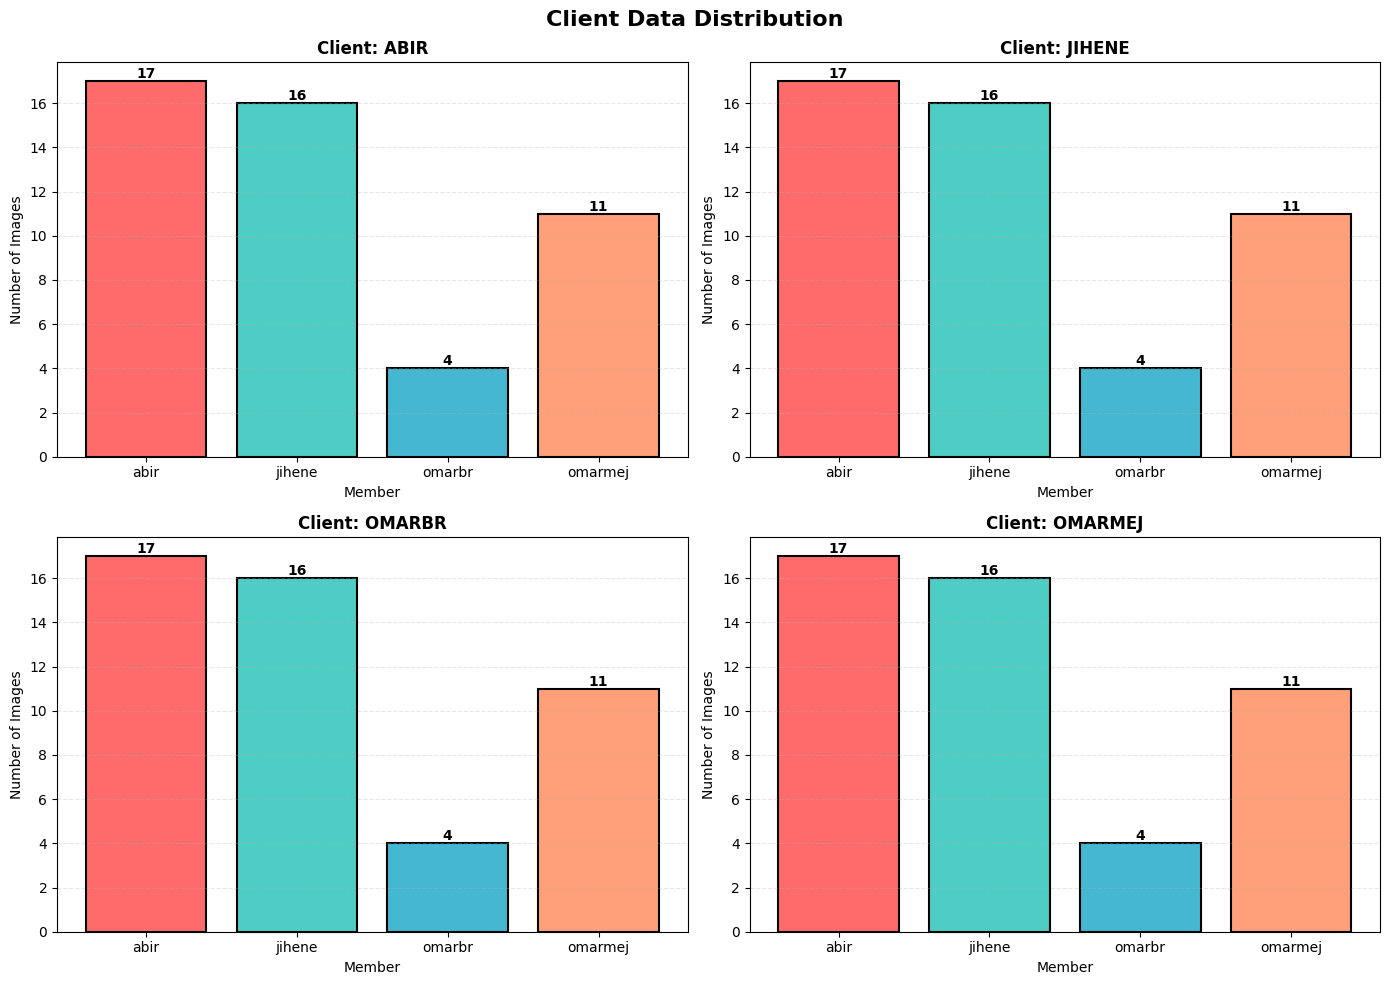

Data exploration completed!


In [3]:
# Visualize data distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Client Data Distribution', fontsize=16, fontweight='bold')

for idx, client in enumerate(CLIENTS):
    ax = axes[idx // 2, idx % 2]
    
    if client in client_data_stats:
        members = list(client_data_stats[client].keys())
        counts = list(client_data_stats[client].values())
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
        bars = ax.bar(members, counts, color=colors, edgecolor='black', linewidth=1.5)
        
        ax.set_title(f'Client: {client.upper()}', fontweight='bold', fontsize=12)
        ax.set_ylabel('Number of Images', fontsize=10)
        ax.set_xlabel('Member', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Data exploration completed!")

## 3. Custom Dataset and Data Preparation

In [4]:
# Custom PyTorch Dataset for facial recognition
class ClientFaceDataset(Dataset):
    """Custom dataset for loading facial images from client folders"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            # Load image
            image = Image.open(img_path).convert('RGB')
            
            # Apply transformations
            if self.transform:
                image = self.transform(image)
            else:
                image = transforms.ToTensor()(image)
            
            return image, label
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a black image as fallback
            return torch.zeros(3, 224, 224), label


def load_client_data(client_name):
    """Load data for a specific client from their folder"""
    client_path = CLIENT_DATA_PATH / f'client_{client_name}'
    
    image_paths = []
    labels = []
    label_map = {member: idx for idx, member in enumerate(CLIENTS)}
    
    # Load images from all member folders
    for member_idx, member in enumerate(CLIENTS):
        member_path = client_path / member
        if member_path.exists():
            images = sorted(list(member_path.glob('*.jpg')) + list(member_path.glob('*.png')))
            for img_path in images:
                image_paths.append(str(img_path))
                labels.append(member_idx)
    
    return image_paths, labels, label_map


# Define data transforms (with augmentation for training)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Dataset classes defined successfully!")

Dataset classes defined successfully!


In [5]:
# Prepare data loaders for all clients
def prepare_client_loaders(client_name, batch_size=16, test_size=0.2):
    """Prepare train and test data loaders for a client"""
    
    image_paths, labels, label_map = load_client_data(client_name)
    
    # Split data into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        image_paths, labels, test_size=test_size, random_state=42, stratify=labels
    )
    
    # Create datasets
    train_dataset = ClientFaceDataset(X_train, y_train, transform=train_transform)
    test_dataset = ClientFaceDataset(X_test, y_test, transform=test_transform)
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=0
    )
    
    return train_loader, test_loader, label_map, len(image_paths)


# Prepare loaders for all clients
client_loaders = {}
client_label_maps = {}
data_sizes = {}

print("=" * 80)
print("PREPARING DATA LOADERS")
print("=" * 80)

for client in CLIENTS:
    train_loader, test_loader, label_map, total_images = prepare_client_loaders(client, batch_size=8)
    client_loaders[client] = {
        'train': train_loader,
        'test': test_loader
    }
    client_label_maps[client] = label_map
    data_sizes[client] = total_images
    print(f"\n{client}: {total_images} images")
    print(f"  - Train batches: {len(train_loader)}")
    print(f"  - Test batches: {len(test_loader)}")

print("\n" + "=" * 80)

PREPARING DATA LOADERS

abir: 48 images
  - Train batches: 5
  - Test batches: 2

jihene: 48 images
  - Train batches: 5
  - Test batches: 2

omarbr: 48 images
  - Train batches: 5
  - Test batches: 2

omarmej: 48 images
  - Train batches: 5
  - Test batches: 2



## 4. Build Neural Network Model

In [6]:
# Define ResNet18-based model for facial recognition
class FacialRecognitionModel(nn.Module):
    """ResNet18 based model for facial recognition"""
    
    def __init__(self, num_classes=4, pretrained=True):
        super(FacialRecognitionModel, self).__init__()
        
        # Load pretrained ResNet18
        self.resnet = resnet18(pretrained=pretrained)
        
        # Replace the last fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)


def create_model(num_classes=4):
    """Create and return a facial recognition model"""
    model = FacialRecognitionModel(num_classes=num_classes, pretrained=True)
    return model.to(device)


# Test model creation
test_model = create_model()
print("Model Architecture:")
print(test_model)
print(f"\nTotal parameters: {sum(p.numel() for p in test_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in test_model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\malek/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:30<00:00, 1.51MB/s]


Model Architecture:
FacialRecognitionModel(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, mo

## 5. Training and Evaluation Functions

In [7]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, test_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels


def train_client_model(client_name, train_loader, test_loader, epochs=30, learning_rate=0.001):
    """Train a model for a specific client"""
    print(f"\n{'=' * 80}")
    print(f"Training model for client: {client_name.upper()}")
    print(f"{'=' * 80}")
    
    # Create model
    model = create_model(num_classes=4)
    
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_acc = 0
    patience = 10
    patience_counter = 0
    
    for epoch in range(epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, _, _ = validate(model, test_loader, criterion, device)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break
    
    print(f"\nTraining completed for {client_name}")
    return model, history


print("Training functions defined successfully!")

Training functions defined successfully!


## 6. Train Models for All Clients

In [8]:
# Train models for all clients
trained_models = {}
training_histories = {}

for client in CLIENTS:
    train_loader = client_loaders[client]['train']
    test_loader = client_loaders[client]['test']
    
    model, history = train_client_model(
        client, 
        train_loader, 
        test_loader,
        epochs=30,
        learning_rate=0.001
    )
    
    trained_models[client] = model
    training_histories[client] = history

print("\n" + "=" * 80)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 80)


Training model for client: ABIR
Epoch [1/30] - Train Loss: 1.2636, Train Acc: 36.84% - Val Loss: 1.2736, Val Acc: 50.00%
Epoch [5/30] - Train Loss: 0.3298, Train Acc: 89.47% - Val Loss: 4.2666, Val Acc: 40.00%
Epoch [10/30] - Train Loss: 0.2142, Train Acc: 94.74% - Val Loss: 2.3565, Val Acc: 70.00%
Epoch [15/30] - Train Loss: 0.0550, Train Acc: 97.37% - Val Loss: 0.3869, Val Acc: 90.00%
Epoch [20/30] - Train Loss: 0.1216, Train Acc: 97.37% - Val Loss: 1.2568, Val Acc: 70.00%
Epoch [25/30] - Train Loss: 0.0544, Train Acc: 100.00% - Val Loss: 1.2391, Val Acc: 90.00%

Early stopping at epoch 26

Training completed for abir

Training model for client: JIHENE
Epoch [1/30] - Train Loss: 1.1243, Train Acc: 50.00% - Val Loss: 1.0808, Val Acc: 60.00%
Epoch [5/30] - Train Loss: 0.7321, Train Acc: 84.21% - Val Loss: 5.3252, Val Acc: 60.00%
Epoch [10/30] - Train Loss: 0.5417, Train Acc: 81.58% - Val Loss: 3.2165, Val Acc: 70.00%

Early stopping at epoch 12

Training completed for jihene

Training

## 7. Evaluate Model Performance

In [9]:
# Evaluate all models and compute metrics
evaluation_results = {}
confusion_matrices = {}

criterion = nn.CrossEntropyLoss()

print("=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

for client in CLIENTS:
    model = trained_models[client]
    test_loader = client_loaders[client]['test']
    label_map = client_label_maps[client]
    
    val_loss, val_acc, preds, labels = validate(model, test_loader, criterion, device)
    
    # Calculate additional metrics
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    recall = recall_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    
    # Store results
    evaluation_results[client] = {
        'val_loss': val_loss,
        'val_acc': val_acc,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    
    # Compute confusion matrix
    cm = confusion_matrix(labels, preds)
    confusion_matrices[client] = cm
    
    print(f"\n{client.upper()}")
    print(f"  Validation Loss: {val_loss:.4f}")
    print(f"  Validation Accuracy: {val_acc:.2f}%")
    print(f"  Precision (weighted): {precision:.4f}")
    print(f"  Recall (weighted): {recall:.4f}")
    print(f"  F1-Score (weighted): {f1:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

print("\n" + "=" * 80)

MODEL EVALUATION

ABIR
  Validation Loss: 1.4172
  Validation Accuracy: 90.00%
  Precision (weighted): 0.8333
  Recall (weighted): 0.9000
  F1-Score (weighted): 0.8600
  Confusion Matrix:
[[4 0 0 0]
 [0 3 0 0]
 [0 0 0 1]
 [0 0 0 2]]

JIHENE
  Validation Loss: 0.5102
  Validation Accuracy: 80.00%
  Precision (weighted): 0.7667
  Recall (weighted): 0.8000
  F1-Score (weighted): 0.7533
  Confusion Matrix:
[[4 0 0 0]
 [0 3 0 0]
 [1 0 0 0]
 [1 0 0 1]]

OMARBR
  Validation Loss: 0.3342
  Validation Accuracy: 90.00%
  Precision (weighted): 0.8200
  Recall (weighted): 0.9000
  F1-Score (weighted): 0.8556
  Confusion Matrix:
[[4 0 0 0]
 [0 3 0 0]
 [1 0 0 0]
 [0 0 0 2]]

OMARMEJ
  Validation Loss: 0.8192
  Validation Accuracy: 80.00%
  Precision (weighted): 0.8000
  Recall (weighted): 0.8000
  F1-Score (weighted): 0.8000
  Confusion Matrix:
[[3 0 0 1]
 [0 3 0 0]
 [0 0 1 0]
 [1 0 0 1]]



## 8. Visualize Training Results

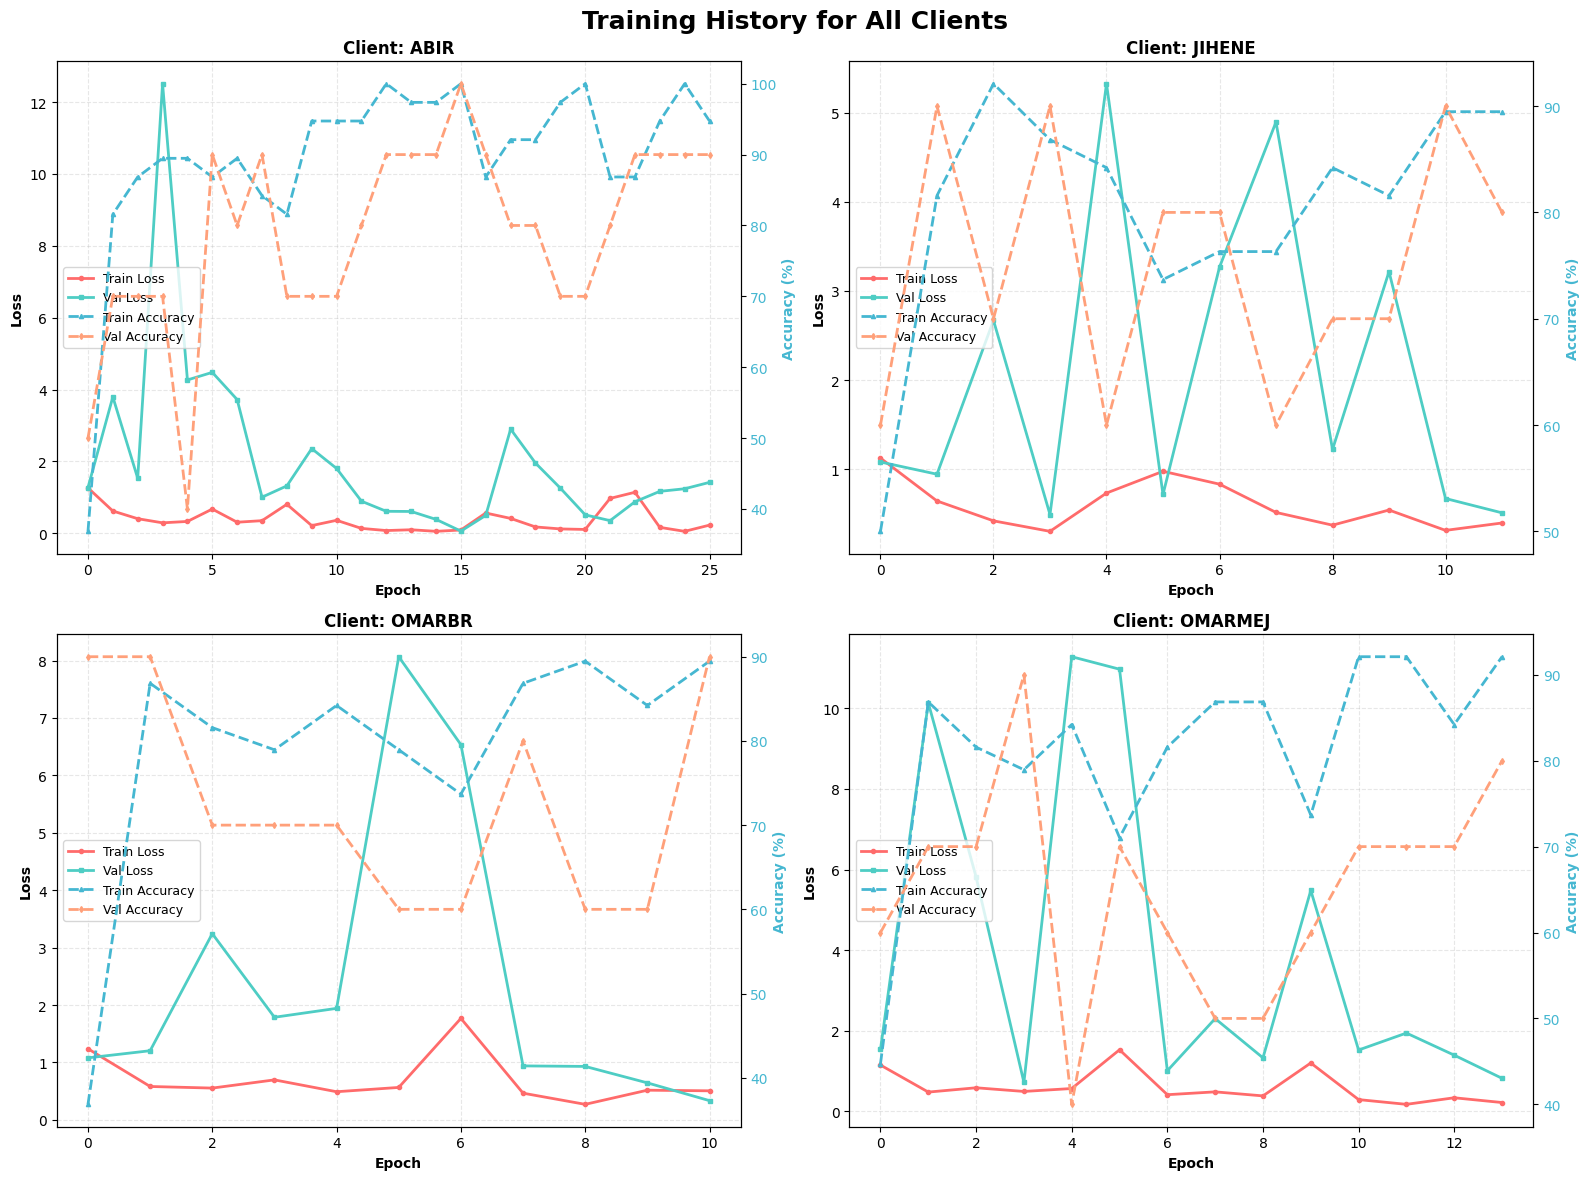

Training curves visualization completed!


In [10]:
# Visualize training curves for all clients
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training History for All Clients', fontsize=18, fontweight='bold')

for idx, client in enumerate(CLIENTS):
    ax = axes[idx // 2, idx % 2]
    history = training_histories[client]
    
    # Plot loss
    ax_loss = ax
    ax_loss.plot(history['train_loss'], label='Train Loss', linewidth=2, color='#FF6B6B', marker='o', markersize=3)
    ax_loss.plot(history['val_loss'], label='Val Loss', linewidth=2, color='#4ECDC4', marker='s', markersize=3)
    ax_loss.set_xlabel('Epoch', fontsize=10, fontweight='bold')
    ax_loss.set_ylabel('Loss', fontsize=10, fontweight='bold', color='black')
    ax_loss.tick_params(axis='y', labelcolor='black')
    ax_loss.grid(True, alpha=0.3, linestyle='--')
    
    # Plot accuracy on secondary y-axis
    ax_acc = ax_loss.twinx()
    ax_acc.plot(history['train_acc'], label='Train Accuracy', linewidth=2, color='#45B7D1', 
                linestyle='--', marker='^', markersize=3)
    ax_acc.plot(history['val_acc'], label='Val Accuracy', linewidth=2, color='#FFA07A', 
                linestyle='--', marker='d', markersize=3)
    ax_acc.set_ylabel('Accuracy (%)', fontsize=10, fontweight='bold', color='#45B7D1')
    ax_acc.tick_params(axis='y', labelcolor='#45B7D1')
    
    ax_loss.set_title(f'Client: {client.upper()}', fontweight='bold', fontsize=12)
    
    # Combine legends
    lines1, labels1 = ax_loss.get_legend_handles_labels()
    lines2, labels2 = ax_acc.get_legend_handles_labels()
    ax_loss.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=9)

plt.tight_layout()
plt.show()

print("Training curves visualization completed!")

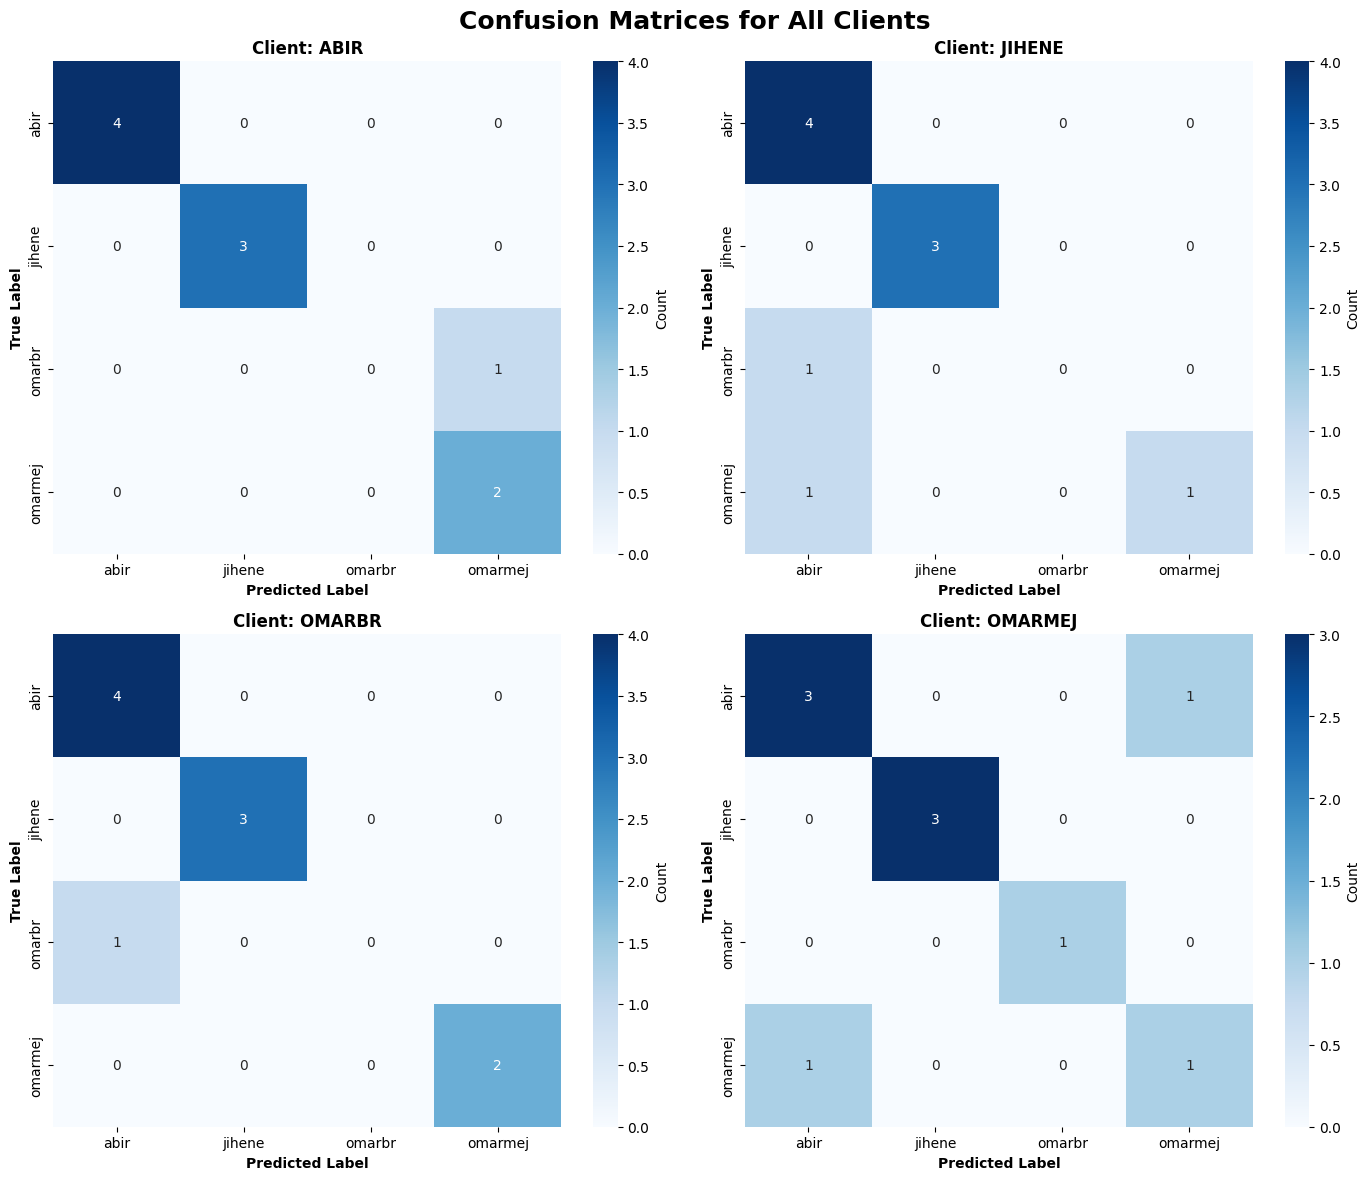

Confusion matrices visualization completed!


In [11]:
# Visualize Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices for All Clients', fontsize=18, fontweight='bold')

class_labels = CLIENTS

for idx, client in enumerate(CLIENTS):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrices[client]
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label': 'Count'})
    
    ax.set_title(f'Client: {client.upper()}', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Confusion matrices visualization completed!")

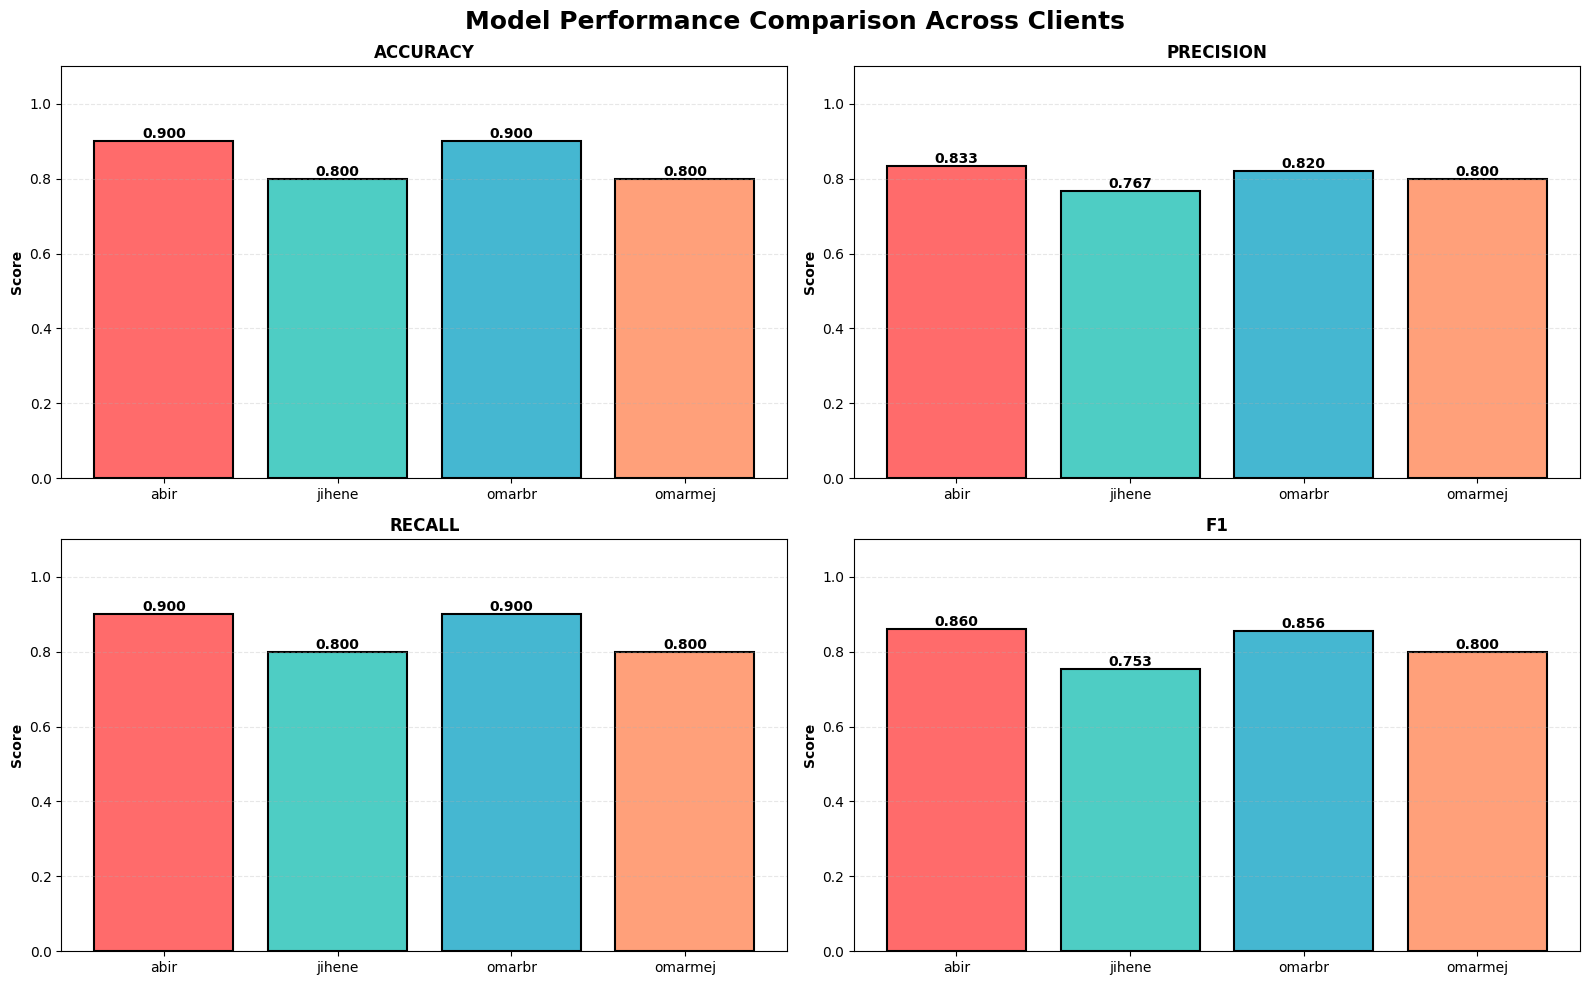

Performance comparison visualization completed!


In [12]:
# Performance Comparison Across All Clients
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Performance Comparison Across Clients', fontsize=18, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Extract data for plotting
client_names = list(evaluation_results.keys())
metric_values = {metric: [evaluation_results[client][metric] for client in client_names] 
                 for metric in metrics}

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    values = metric_values[metric]
    bars = ax.bar(client_names, values, color=colors, edgecolor='black', linewidth=1.5)
    
    ax.set_title(f'{metric.upper()}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}',
               ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("Performance comparison visualization completed!")

In [13]:
# Create comprehensive performance table
performance_df = pd.DataFrame(evaluation_results).T
performance_df = performance_df[['val_acc', 'accuracy', 'precision', 'recall', 'f1']]
performance_df.columns = ['Val Accuracy (%)', 'Accuracy', 'Precision', 'Recall', 'F1-Score']

print("\n" + "=" * 100)
print("COMPREHENSIVE PERFORMANCE TABLE")
print("=" * 100)
print(performance_df.round(4))
print("=" * 100)

# Calculate and display summary statistics
print("\nSummary Statistics:")
print(f"Average Accuracy: {performance_df['Accuracy'].mean():.4f}")
print(f"Average Precision: {performance_df['Precision'].mean():.4f}")
print(f"Average Recall: {performance_df['Recall'].mean():.4f}")
print(f"Average F1-Score: {performance_df['F1-Score'].mean():.4f}")
print(f"\nBest Performing Client: {performance_df['Accuracy'].idxmax()} ({performance_df['Accuracy'].max():.4f})")
print(f"Lowest Performing Client: {performance_df['Accuracy'].idxmin()} ({performance_df['Accuracy'].min():.4f})")


COMPREHENSIVE PERFORMANCE TABLE
         Val Accuracy (%)  Accuracy  Precision  Recall  F1-Score
abir                 90.0       0.9     0.8333     0.9    0.8600
jihene               80.0       0.8     0.7667     0.8    0.7533
omarbr               90.0       0.9     0.8200     0.9    0.8556
omarmej              80.0       0.8     0.8000     0.8    0.8000

Summary Statistics:
Average Accuracy: 0.8500
Average Precision: 0.8050
Average Recall: 0.8500
Average F1-Score: 0.8172

Best Performing Client: abir (0.9000)
Lowest Performing Client: jihene (0.8000)


## 9. Save Trained Models

In [14]:
# Save trained models
import time

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("=" * 80)
print("SAVING TRAINED MODELS")
print("=" * 80)

saved_models_info = {}

for client in CLIENTS:
    model = trained_models[client]
    
    # Save model weights
    model_filename = f'{client}_model_{timestamp}.pt'
    model_path = MODELS_OUTPUT_PATH / model_filename
    torch.save(model.state_dict(), model_path)
    
    saved_models_info[client] = {
        'model_path': str(model_path),
        'model_file': model_filename,
        'accuracy': evaluation_results[client]['accuracy'],
        'f1_score': evaluation_results[client]['f1']
    }
    
    print(f"\n✓ {client.upper()}")
    print(f"  Model saved: {model_filename}")
    print(f"  Full path: {model_path}")
    print(f"  Final Accuracy: {evaluation_results[client]['accuracy']:.4f}")
    print(f"  F1-Score: {evaluation_results[client]['f1']:.4f}")

# Save metadata and results
results_filename = f'local_training_results_{timestamp}.json'
results_path = MODELS_OUTPUT_PATH / results_filename

results_data = {
    'timestamp': timestamp,
    'training_date': datetime.now().isoformat(),
    'models': saved_models_info,
    'evaluation_results': {
        client: {k: float(v) for k, v in results.items()}
        for client, results in evaluation_results.items()
    },
    'data_sizes': data_sizes,
    'training_config': {
        'epochs': 30,
        'learning_rate': 0.001,
        'batch_size': 8,
        'device': str(device),
        'model_architecture': 'ResNet18-based with custom FC layers'
    }
}

with open(results_path, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f"\n\n✓ Training results saved: {results_filename}")
print(f"  Full path: {results_path}")

print("\n" + "=" * 80)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("=" * 80)
print(f"\nModels output directory: {MODELS_OUTPUT_PATH}")
print(f"Total files saved: {len(CLIENTS) + 1}")  # Models + results JSON

SAVING TRAINED MODELS

✓ ABIR
  Model saved: abir_model_20251202_113112.pt
  Full path: C:\Users\malek\OneDrive\Bureau\federated learning\models\local models\abir_model_20251202_113112.pt
  Final Accuracy: 0.9000
  F1-Score: 0.8600

✓ JIHENE
  Model saved: jihene_model_20251202_113112.pt
  Full path: C:\Users\malek\OneDrive\Bureau\federated learning\models\local models\jihene_model_20251202_113112.pt
  Final Accuracy: 0.8000
  F1-Score: 0.7533

✓ OMARBR
  Model saved: omarbr_model_20251202_113112.pt
  Full path: C:\Users\malek\OneDrive\Bureau\federated learning\models\local models\omarbr_model_20251202_113112.pt
  Final Accuracy: 0.9000
  F1-Score: 0.8556

✓ OMARMEJ
  Model saved: omarmej_model_20251202_113112.pt
  Full path: C:\Users\malek\OneDrive\Bureau\federated learning\models\local models\omarmej_model_20251202_113112.pt
  Final Accuracy: 0.8000
  F1-Score: 0.8000


✓ Training results saved: local_training_results_20251202_113112.json
  Full path: C:\Users\malek\OneDrive\Bureau\f

## 10. Summary and Key Findings

In [15]:
# Generate comprehensive summary report
print("\n" + "=" * 100)
print("LOCAL FEDERATED LEARNING PIPELINE - SUMMARY REPORT".center(100))
print("=" * 100)

print("\n📊 DATASET SUMMARY")
print("-" * 100)
for client in CLIENTS:
    total = data_sizes[client]
    print(f"  {client.upper():12} - Total images: {total:3d}")

print("\n🤖 MODEL ARCHITECTURE")
print("-" * 100)
print("  Base Model: ResNet18 (pretrained on ImageNet)")
print("  Input Size: 224 x 224 pixels")
print("  Output Classes: 4 (abir, jihene, omarbr, omarmej)")
print("  Custom FC Layers: 512 → 256 → 4")
print("  Activation: ReLU with Dropout(0.5)")
print("  Optimizer: Adam (lr=0.001)")
print("  Loss Function: CrossEntropyLoss")

print("\n📈 TRAINING CONFIGURATION")
print("-" * 100)
print("  Epochs: 30 (with early stopping, patience=10)")
print("  Batch Size: 8")
print("  Data Augmentation: Horizontal flip, Rotation(15°), ColorJitter, Affine transforms")
print("  Train/Test Split: 80/20")
print("  Device:", str(device).upper())

print("\n🎯 PERFORMANCE RESULTS")
print("-" * 100)
print(performance_df.to_string())

print("\n📊 STATISTICAL SUMMARY")
print("-" * 100)
print(f"  Average Accuracy:  {performance_df['Accuracy'].mean():.4f}")
print(f"  Average Precision: {performance_df['Precision'].mean():.4f}")
print(f"  Average Recall:    {performance_df['Recall'].mean():.4f}")
print(f"  Average F1-Score:  {performance_df['F1-Score'].mean():.4f}")

print("\n⭐ BEST PERFORMERS")
print("-" * 100)
best_acc_client = performance_df['Accuracy'].idxmax()
best_f1_client = performance_df['F1-Score'].idxmax()
print(f"  Highest Accuracy:  {best_acc_client.upper()} ({performance_df.loc[best_acc_client, 'Accuracy']:.4f})")
print(f"  Highest F1-Score:  {best_f1_client.upper()} ({performance_df.loc[best_f1_client, 'F1-Score']:.4f})")

print("\n💾 MODEL PERSISTENCE")
print("-" * 100)
print(f"  Output Directory: {MODELS_OUTPUT_PATH}")
for client in CLIENTS:
    print(f"    ✓ {client}_model_{timestamp}.pt")
print(f"    ✓ local_training_results_{timestamp}.json")

print("\n✅ PIPELINE EXECUTION COMPLETED")
print("=" * 100)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 100)


                         LOCAL FEDERATED LEARNING PIPELINE - SUMMARY REPORT                         

📊 DATASET SUMMARY
----------------------------------------------------------------------------------------------------
  ABIR         - Total images:  48
  JIHENE       - Total images:  48
  OMARBR       - Total images:  48
  OMARMEJ      - Total images:  48

🤖 MODEL ARCHITECTURE
----------------------------------------------------------------------------------------------------
  Base Model: ResNet18 (pretrained on ImageNet)
  Input Size: 224 x 224 pixels
  Output Classes: 4 (abir, jihene, omarbr, omarmej)
  Custom FC Layers: 512 → 256 → 4
  Activation: ReLU with Dropout(0.5)
  Optimizer: Adam (lr=0.001)
  Loss Function: CrossEntropyLoss

📈 TRAINING CONFIGURATION
----------------------------------------------------------------------------------------------------
  Epochs: 30 (with early stopping, patience=10)
  Batch Size: 8
  Data Augmentation: Horizontal flip, Rotation(15°), ColorJ